import all necessory libraries

In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

Load Tesla deliveries dataset

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("nalisha/tesla-ea-deliveries-and-production-data20152025")

print(os.listdir(path))

C:\Users\MAYANK CHAUHAN\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████████████████████████████████████████████████████████████████████████| 64.8k/64.8k [00:00<00:00, 271kB/s]

Extracting files...
['tesla_deliveries_dataset_2015_2025.csv']


In [3]:
df = pd.read_csv(
    os.path.join(path, "tesla_deliveries_dataset_2015_2025.csv")
)

perform Basic EDA using head(), tail(), info(), describe()

In [4]:
df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [5]:
df.tail()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
2635,2021,10,Middle East,Model Y,13488,14333,113771.10,120,719,1454.68,Official (Quarter),4273
2636,2019,7,Middle East,Model S,18300,18407,81889.67,82,487,1336.81,Official (Quarter),9833
2637,2019,9,Asia,Model S,13291,14839,97139.38,100,580,1156.32,Estimated (Region),13709
2638,2020,5,Asia,Cybertruck,3471,3714,69990.57,60,358,186.39,Interpolated (Month),6754
2639,2018,8,North America,Model S,2639,2929,51676.24,82,474,187.63,Estimated (Region),14297


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


There is no missing value.

In [7]:
df.describe()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


perform univariate analysis for numerical data

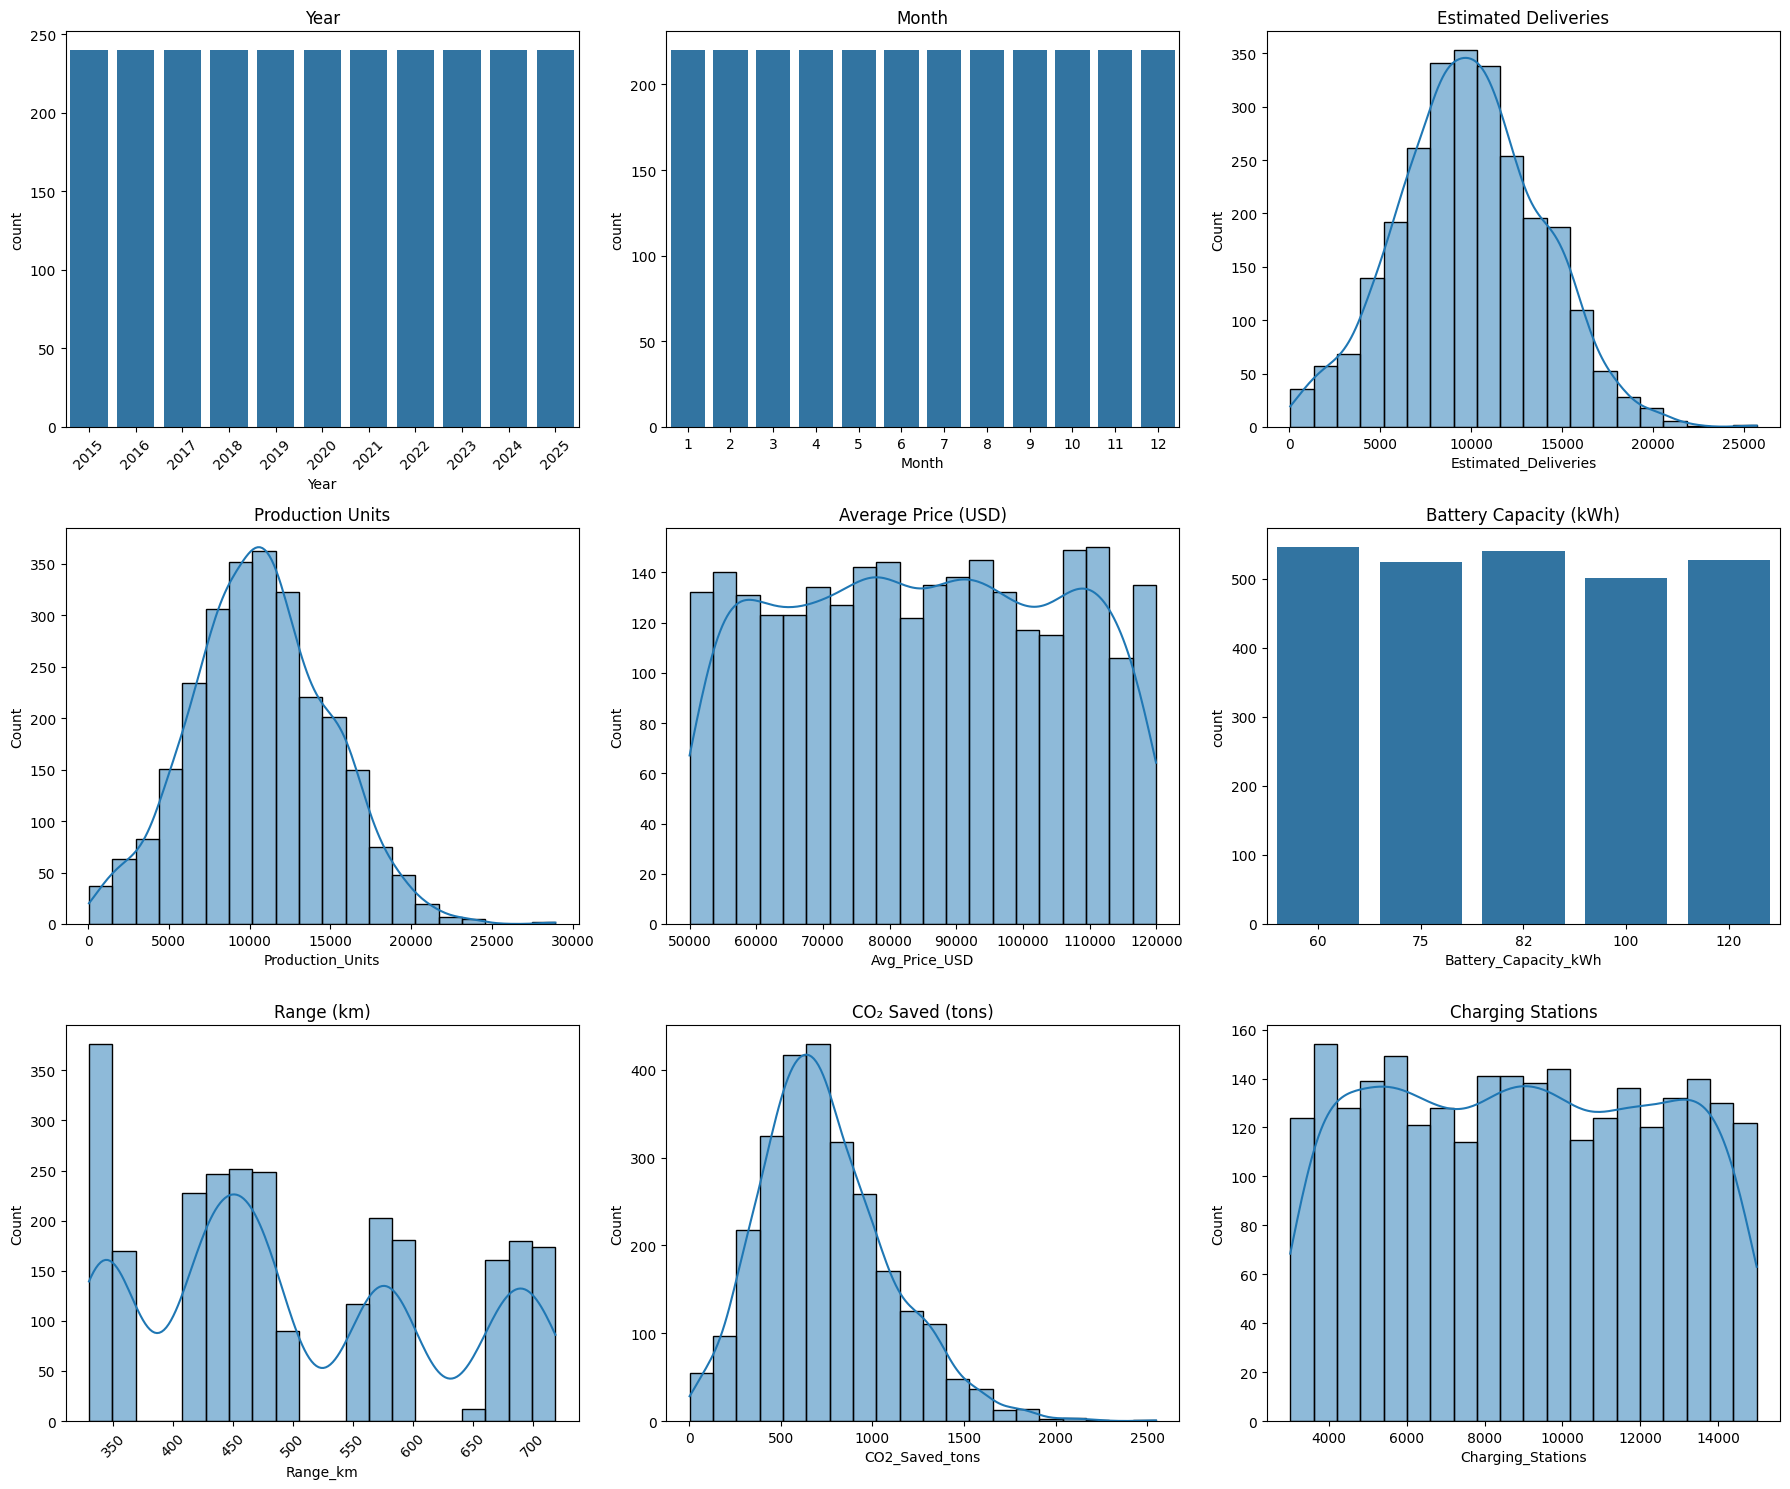

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create figure
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()

# 1. Year (Discrete)
sns.countplot(data=df, x="Year", ax=axes[0])
axes[0].set_title("Year")
axes[0].tick_params(axis='x', rotation=45)

# 2. Month (Discrete)
sns.countplot(data=df, x="Month", ax=axes[1])
axes[1].set_title("Month")

# 3. Estimated Deliveries (Continuous)
sns.histplot(df["Estimated_Deliveries"], bins=20, kde=True, ax=axes[2])
axes[2].set_title("Estimated Deliveries")

# 4. Production Units (Continuous)
sns.histplot(df["Production_Units"], bins=20, kde=True, ax=axes[3])
axes[3].set_title("Production Units")

# 5. Average Price (Continuous)
sns.histplot(df["Avg_Price_USD"], bins=20, kde=True, ax=axes[4])
axes[4].set_title("Average Price (USD)")

# 6. Battery Capacity (Discrete)
sns.countplot(data=df, x="Battery_Capacity_kWh", ax=axes[5])
axes[5].set_title("Battery Capacity (kWh)")

# 7. Range (Discrete)
sns.histplot(df["Range_km"], bins=20, kde=True, ax=axes[6])
axes[6].set_title("Range (km)")
axes[6].tick_params(axis='x', rotation=45)

# 8. CO2 Saved (Continuous)
sns.histplot(df["CO2_Saved_tons"], bins=20, kde=True, ax=axes[7])
axes[7].set_title("CO₂ Saved (tons)")

# 9. Charging Stations (Continuous)
sns.histplot(df["Charging_Stations"], bins=20, kde=True, ax=axes[8])
axes[8].set_title("Charging Stations")

plt.tight_layout()
plt.show()

1. In Year, it is uniform with counts 220.
2. In Month, it is also uniform with counts 220.
3. Estimated_Deliveries, it is close to the normal distribution. most delivery lie between 7k to 13k units.
4. Productin_units, it is close to the noraml distribution. most production lies between 8k to 15k.
5. Avg_Price_USD, prices are almost uniformly distributed between $50k and $120k.
6. Battery_Capacity, it takes discrete values, most values around 60,75,80,95,120kWh.
7. Range (km), Most vehicles have ranges between 350 km and 720 km.
8. CO₂ Saved (tons), distribuiton is right skewed, most observations lie between 400 and 1,000 tons.
9. Chargin Stations counts are almost uniform lie between 3k to 15k.

perform bivariate analysis

<Axes: xlabel='Production_Units', ylabel='Estimated_Deliveries'>

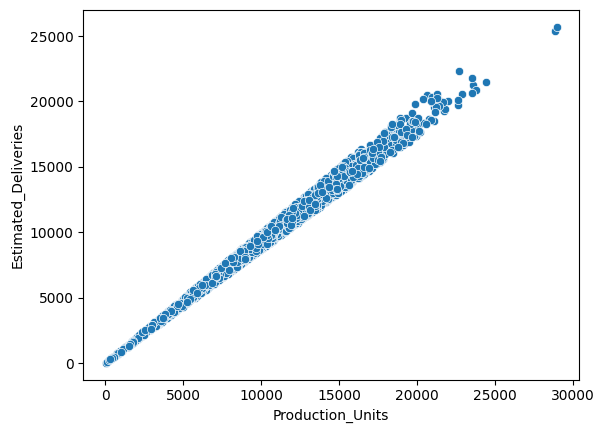

In [9]:
sns.scatterplot(data =df, x="Production_Units",y="Estimated_Deliveries")


<Axes: xlabel='Avg_Price_USD', ylabel='Estimated_Deliveries'>

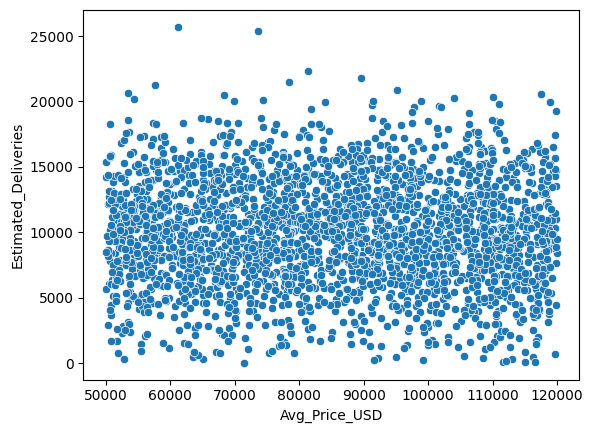

In [10]:
sns.scatterplot(data =df, x="Avg_Price_USD",y="Estimated_Deliveries")


<Axes: xlabel='Charging_Stations', ylabel='Estimated_Deliveries'>

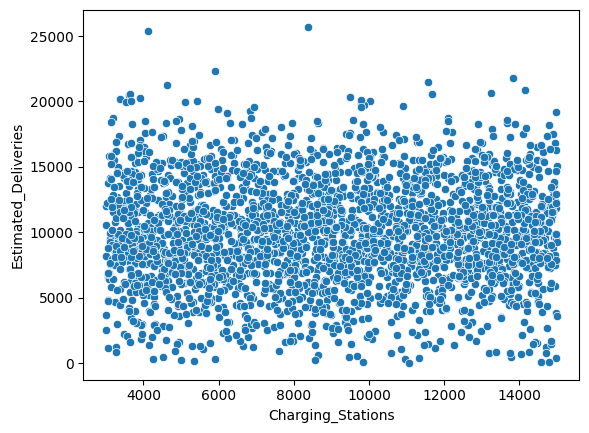

In [11]:
sns.scatterplot(data =df, x="Charging_Stations",y="Estimated_Deliveries")


<Axes: xlabel='Range_km', ylabel='Estimated_Deliveries'>

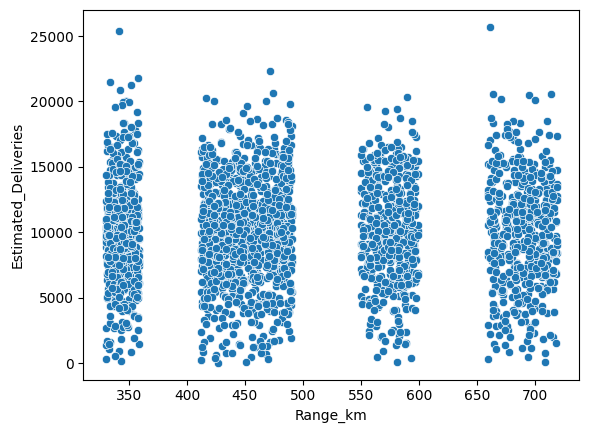

In [12]:
sns.scatterplot(data =df, x="Range_km",y="Estimated_Deliveries")


<Axes: xlabel='CO2_Saved_tons', ylabel='Estimated_Deliveries'>

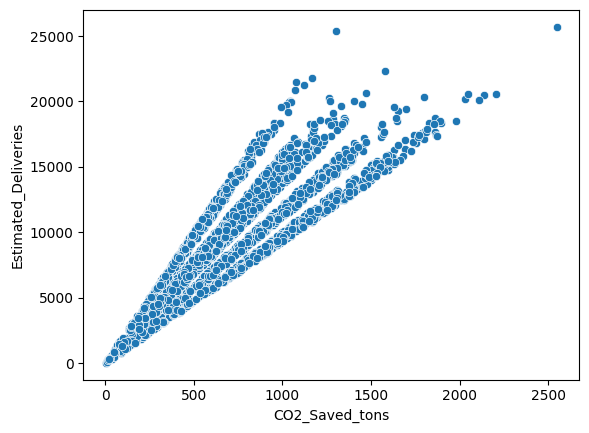

In [13]:
sns.scatterplot(data =df, x="CO2_Saved_tons",y="Estimated_Deliveries")

Production Units vs Estimated Deliveries: Estimated deliveries increase almost linearly with production units, indicating a strong positive correlation.
Avg_Price_USD vs Estimated Deliveries: Average vehicle price shows little to no correlation with estimated deliveries.
Charging_Stations vs Estimated Deliveries: The number of charging stations does not exhibit a clear relationship with estimated deliveries.
Range_km vs Estimated Deliveries: Vehicle range has no significant impact on estimated deliveries.
CO2_Saved_tons vs Estimated Deliveries: CO₂ saved increases with estimated deliveries, showing a strong positive correlation.

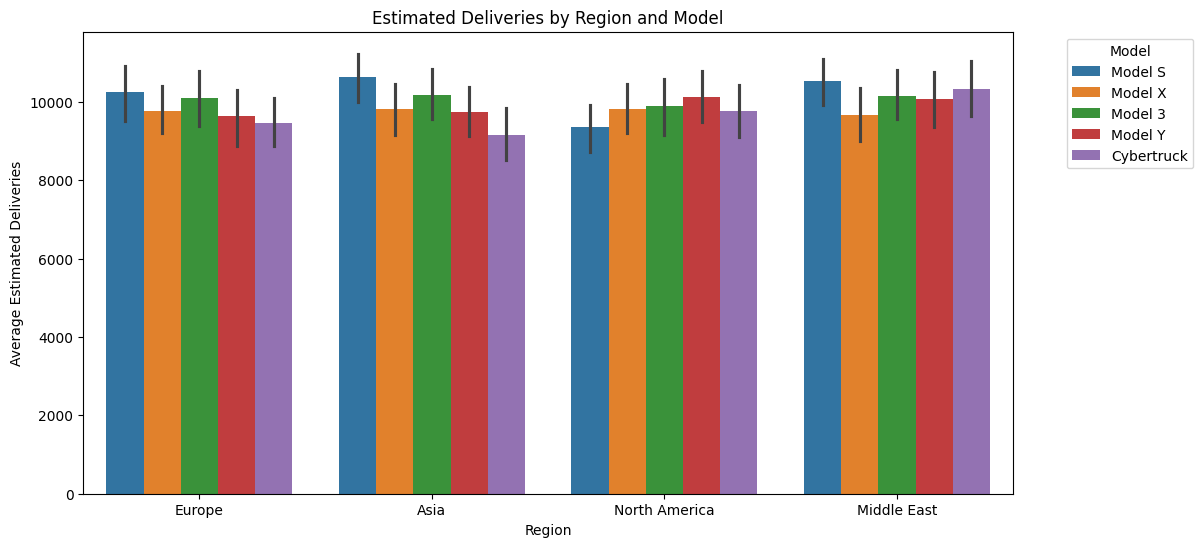

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))
sns.barplot(
    data=df,
    x="Region",
    y="Estimated_Deliveries",
    hue="Model"
)

plt.title("Estimated Deliveries by Region and Model")
plt.xlabel("Region")
plt.ylabel("Average Estimated Deliveries")
plt.legend(title="Model", bbox_to_anchor=(1.05,1), loc="upper left")
plt.show()

The average estimated deliveries are relatively consistent across all region–model combinations, indicating only minor regional differences.
Model S records the highest average deliveries in Asia and the Middle East, while Model Y performs slightly better in North America.
Cybertruck shows comparatively lower average deliveries in Europe and Asia, but performs better in the Middle East.
Overall, neither the region nor the vehicle model has a significant impact on the average estimated deliveries in this dataset.

Correlation Heatmap

<Axes: >

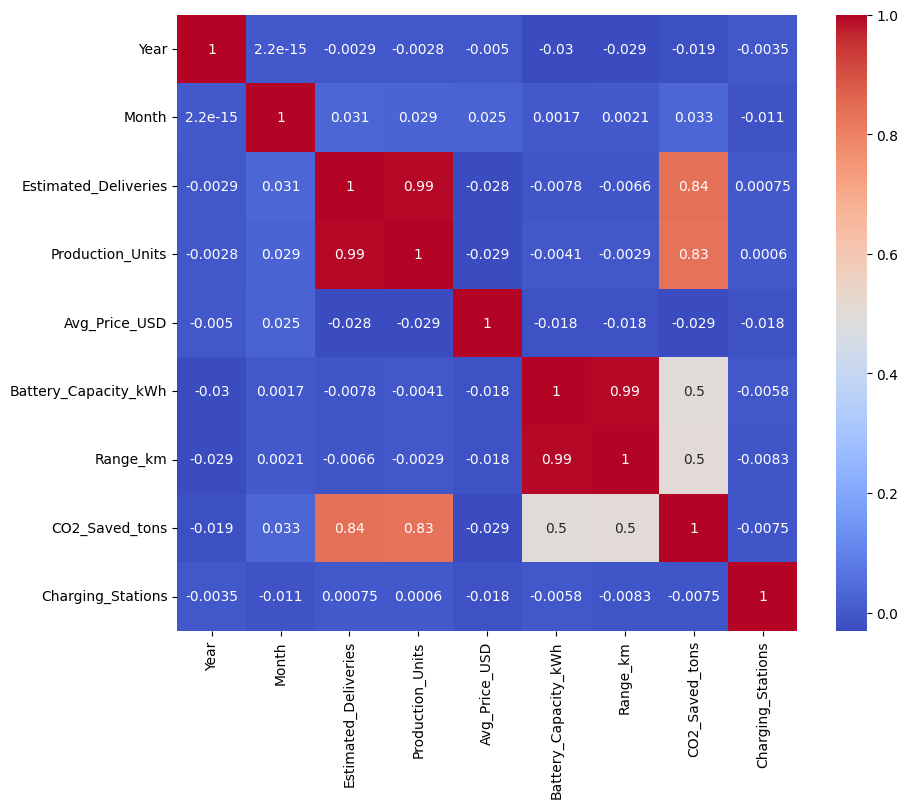

In [15]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap="coolwarm"
)

In [16]:
Estimated_Deliveries has a very strong positive correlation with Production_Units (0.99) and a strong positive correlation with CO2_Saved_tons (0.84).
Battery_Capacity_kWh and Range_km are also highly correlated (0.99), indicating that vehicles with larger battery capacities generally have higher driving ranges.
Most other feature pairs have correlations close to zero, suggesting weak or no linear relationship between them.

SyntaxError: invalid syntax (2966020738.py, line 1)

Outliers Detection

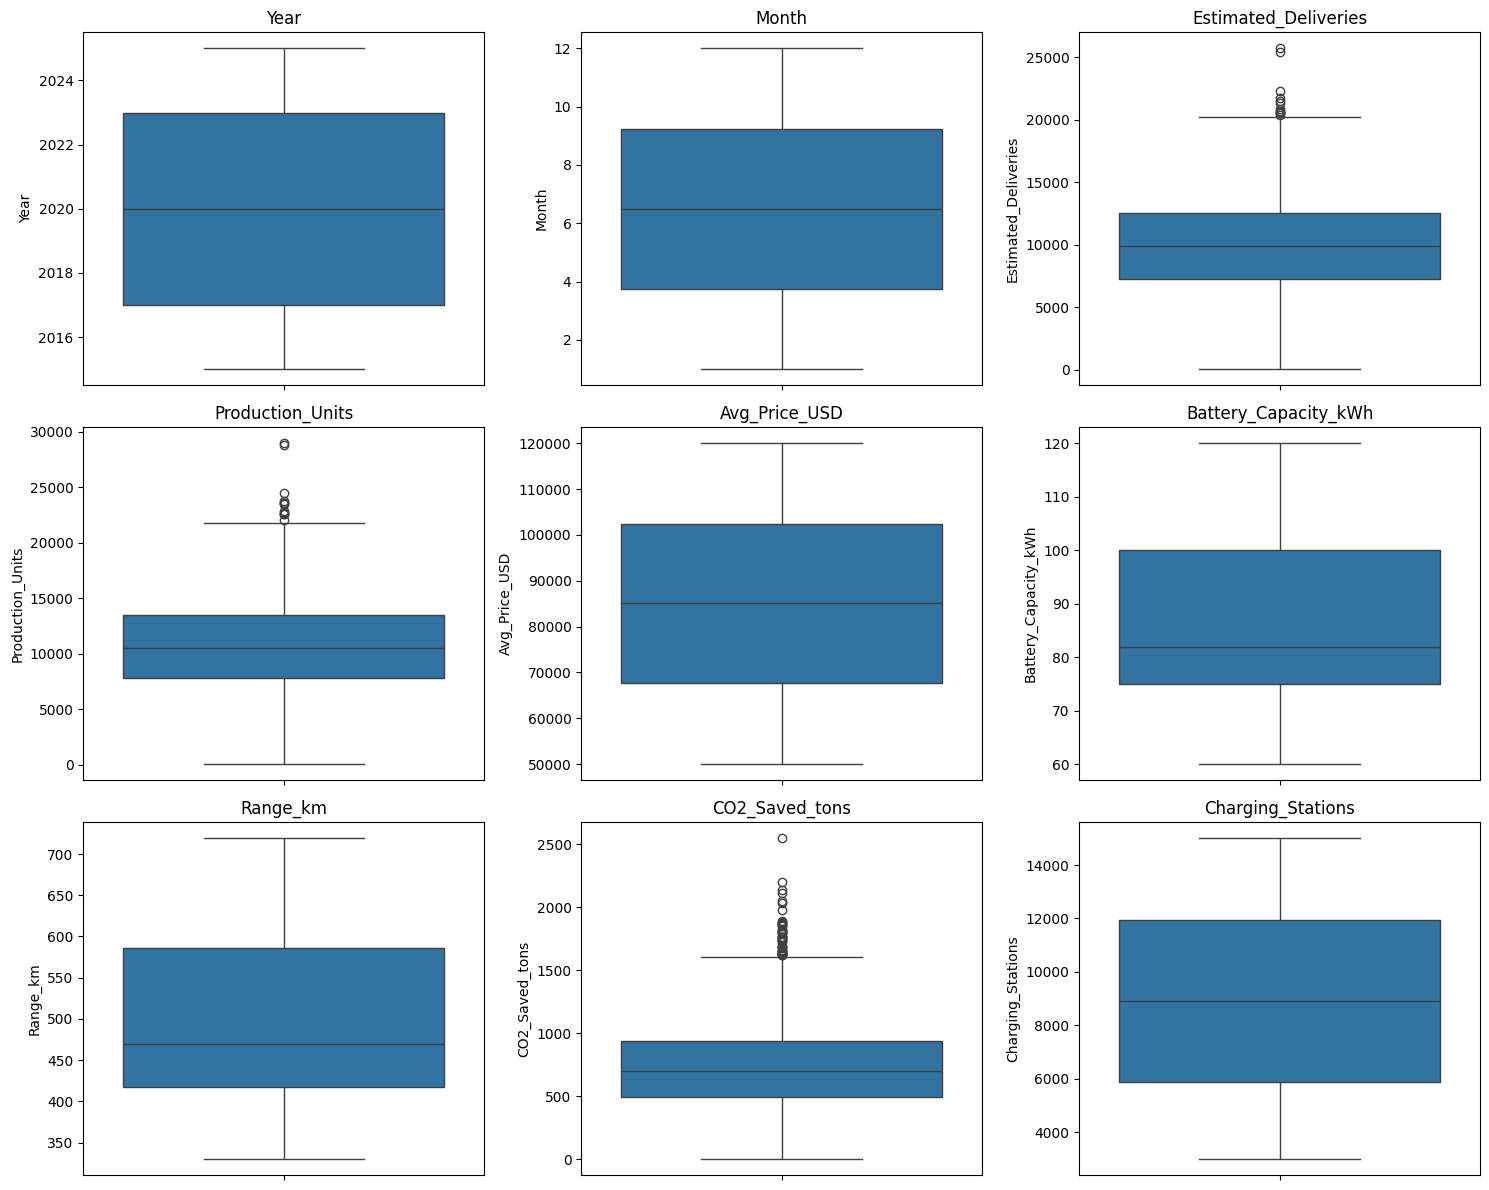

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = df.select_dtypes(include='number').columns

plt.figure(figsize=(15,12))

for i, col in enumerate(num_cols):
    plt.subplot(3,3,i+1)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

Estimated_Deliveries, Production_Units, and CO2_Saved_tons contain a few upper-end outliers, indicating some observations have unusually high values.
Year, Month, Avg_Price_USD, Battery_Capacity_kWh, Range_km, and Charging_Stations show little to no significant outliers and have relatively stable distributions.

Remove outliers using the IQR method

In [18]:
# Columns with outliers
cols = ["Estimated_Deliveries", "Production_Units", "CO2_Saved_tons"]

df_clean = df.copy()

for col in cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df_clean = df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)]

print("Original Shape:", df.shape)
print("New Shape:", df_clean.shape)
print("Rows Removed:", df.shape[0] - df_clean.shape[0])

Original Shape: (2640, 12)
New Shape: (2585, 12)
Rows Removed: 55


Feature Enginnering

In [19]:
df_clean["Date"] = pd.to_datetime(
    dict(
        year=df_clean["Year"],
        month=df_clean["Month"],
        day=1
    )
)
df_clean["Quarter"] = df_clean["Date"].dt.quarter

df_clean["Month_Name"] = df_clean["Date"].dt.month_name()

df_clean["Price_per_km"] = (
    df_clean["Avg_Price_USD"] /
    df_clean["Range_km"]
)

df_clean["Premium_Model"] = (
    df_clean["Avg_Price_USD"] > 90000
).astype(int)

df_clean["Long_Range"] = (
    df_clean["Range_km"] >= 600
).astype(int)

df_clean["High_Battery"] = (
    df_clean["Battery_Capacity_kWh"] >= 100
).astype(int)

df_clean["Production_Category"] = pd.cut(
    df_clean["Production_Units"],
    bins=3,
    labels=["Low","Medium","High"]
)

df_clean["Price_Category"] = pd.cut(
    df_clean["Avg_Price_USD"],
    bins=3,
    labels=["Budget","Mid","Premium"]
)

check newly created columns are usefull or not

In [20]:
corr = df_clean.corr(numeric_only=True)
corr["Estimated_Deliveries"].sort_values(ascending=False)

Estimated_Deliveries    1.000000
Production_Units        0.993947
CO2_Saved_tons          0.827396
Quarter                 0.031586
Month                   0.027073
Charging_Stations       0.008190
Year                    0.005542
Price_per_km            0.003987
Avg_Price_USD          -0.030212
Premium_Model          -0.036640
High_Battery           -0.038642
Range_km               -0.050182
Battery_Capacity_kWh   -0.052568
Long_Range             -0.074763
Name: Estimated_Deliveries, dtype: float64

In [21]:
df_clean.groupby("Price_Category")["Estimated_Deliveries"].mean()

C:\Users\MAYANK CHAUHAN\AppData\Local\Temp\ipykernel_2880\4132809612.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_clean.groupby("Price_Category")["Estimated_Deliveries"].mean()


Price_Category
Budget      9696.592244
Mid        10060.789831
Premium     9450.134276
Name: Estimated_Deliveries, dtype: float64

In [22]:
df_clean.groupby("Production_Category")["Estimated_Deliveries"].mean()

C:\Users\MAYANK CHAUHAN\AppData\Local\Temp\ipykernel_2880\2953598272.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_clean.groupby("Production_Category")["Estimated_Deliveries"].mean()


Production_Category
Low        4622.596460
Medium     9989.037132
High      15205.502183
Name: Estimated_Deliveries, dtype: float64

Correlation with Estimated Deliveries
Production_Units (0.99) and CO2_Saved_tons (0.83) exhibit a strong positive correlation with estimated deliveries, making them the most influential features.
The engineered features Price_per_km, Premium_Model, High_Battery, and Long_Range have very weak correlations, indicating they contribute little to predicting estimated deliveries.
Quarter and Month also show only a weak relationship with the target variable.
Price_Category vs Estimated Deliveries
Vehicles in the Mid price category have the highest average estimated deliveries, followed by the Budget category.
The Premium price category records the lowest average deliveries, suggesting that higher-priced vehicles are delivered less frequently.
Production_Category vs Estimated Deliveries
Average estimated deliveries increase significantly from Low to High production categories.
The High production category has the highest average deliveries, confirming a strong positive relationship between production volume and deliveries.

Seperate X and Y

In [23]:
X = df_clean.drop(["Estimated_Deliveries","Date"], axis=1)
y = df_clean["Estimated_Deliveries"]

one-hot encoding for categorical data

In [24]:
categorical_cols = [
    "Region",
    "Model",
    "Source_Type",
    "Price_Category",
    "Production_Category",
    "Month_Name"
]

X = pd.get_dummies(
    X,
    columns=categorical_cols,
    drop_first=True
)

In [25]:
X.head()

,Year,Month,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations,Quarter,Price_per_km,...,Month_Name_December,Month_Name_February,Month_Name_January,Month_Name_July,Month_Name_June,Month_Name_March,Month_Name_May,Month_Name_November,Month_Name_October,Month_Name_September
1,2015,2,4164,62205.65,75,438,249.46,7640,1,142.022032,...,False,True,False,False,False,False,False,False,False,False
2,2019,1,9189,117887.32,82,480,605.59,14071,1,245.598583,...,False,False,True,False,False,False,False,False,False,False
3,2021,2,7311,89294.91,120,712,700.07,9333,1,125.414199,...,False,True,False,False,False,False,False,False,False,False
4,2016,12,13537,114846.78,120,661,1226.88,8722,4,173.747020,...,True,False,False,False,False,False,False,False,False,False
5,2020,4,5043,86930.57,82,477,333.14,5798,2,182.244382,...,False,False,False,False,False,False,False,False,False,False


In [26]:
X.columns

Index(['Year', 'Month', 'Production_Units', 'Avg_Price_USD',
       'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons',
       'Charging_Stations', 'Quarter', 'Price_per_km', 'Premium_Model',
       'Long_Range', 'High_Battery', 'Region_Europe', 'Region_Middle East',
       'Region_North America', 'Model_Model 3', 'Model_Model S',
       'Model_Model X', 'Model_Model Y', 'Source_Type_Interpolated (Month)',
       'Source_Type_Official (Quarter)', 'Price_Category_Mid',
       'Price_Category_Premium', 'Production_Category_Medium',
       'Production_Category_High', 'Month_Name_August', 'Month_Name_December',
       'Month_Name_February', 'Month_Name_January', 'Month_Name_July',
       'Month_Name_June', 'Month_Name_March', 'Month_Name_May',
       'Month_Name_November', 'Month_Name_October', 'Month_Name_September'],
      dtype='object')

In [27]:
# train-test-split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [28]:
#feature scaling
from sklearn.preprocessing import StandardScaler

num_cols = [
    "Year",
    "Month",
    "Production_Units",
    "Avg_Price_USD",
    "Battery_Capacity_kWh",
    "Range_km",
    "CO2_Saved_tons",
    "Charging_Stations",
    "Quarter",
    "Price_per_km",
    "Premium_Model",
    "High_Battery",
    "Long_Range"
]

scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [29]:
#train model 
#1. Linear Regression
from sklearn.linear_model import LinearRegression
reg = LinearRegression()
reg.fit(X_train, y_train)

y_pred = reg.predict(X_test)

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("MAE :", mean_absolute_error(y_test, y_pred))
print("MSE :", mean_squared_error(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred) ** 0.5)
print("R² Score:", r2_score(y_test, y_pred))

MAE : 307.63507903114714
MSE : 141581.10182343406
RMSE: 376.27264293784907
R² Score: 0.9894212820044016


The model explains approximately 98.94% of the variance in the target variable, indicating high predictive accuracy. The low error metrics (MAE and RMSE) confirm that the model makes reliable predictions. But, it may overfit the model

In [30]:
#check overfitting using cross validation
from sklearn.model_selection import cross_val_score

scores = cross_val_score(reg, X, y, cv=5, scoring="r2")

print("Cross-validation R² scores:", scores)
print("Average R²:", scores.mean())

Cross-validation R² scores: [0.98956389 0.98967947 0.98908688 0.98971311 0.99034309]
Average R²: 0.9896772877918147


Cross-validation conform that the model is generalize 

In [31]:
#2. decision tree
from sklearn.tree import DecisionTreeRegressor

tree = DecisionTreeRegressor(random_state=42)
tree.fit(X_train, y_train)
y_pred = reg.predict(X_test)
print("MAE :", mean_absolute_error(y_test, y_pred))
print("MSE :", mean_squared_error(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred) ** 0.5)
print("R² Score:", r2_score(y_test, y_pred))

MAE : 307.63507903114714
MSE : 141581.10182343406
RMSE: 376.27264293784907
R² Score: 0.9894212820044016


In [32]:
#check cross_validation
scores = cross_val_score(tree, X, y, cv=5, scoring="r2")

print("Cross-validation R² scores:", scores)
print("Average R²:", scores.mean())

Cross-validation R² scores: [0.976972   0.97930242 0.98006909 0.97869747 0.98121973]
Average R²: 0.9792521431700972


Cross-validation conform that the model is generalize

In [33]:
#3 Random forest
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
rf_pred = y_pred

print("MAE :", mean_absolute_error(y_test, y_pred))
print("MSE :", mean_squared_error(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred) ** 0.5)
print("R² Score:", r2_score(y_test, y_pred))

MAE : 309.5306189555126
MSE : 150074.51056189556
RMSE: 387.39451539986413
R² Score: 0.9887866678171382


In [34]:
#check cross_validation
scores = cross_val_score(rf, X, y, cv=5, scoring="r2")

print("Cross-validation R² scores:", scores)
print("Average R²:", scores.mean())

Cross-validation R² scores: [0.98854454 0.98917723 0.98796557 0.98925608 0.99002841]
Average R²: 0.9889943658280262


Cross-validation conform that the model is generalize

In [35]:
from xgboost import XGBRegressor
xgb = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

xgb.fit(X_train, y_train)
y_pred = xgb.predict(X_test)

print("MAE :", mean_absolute_error(y_test, y_pred))
print("MSE :", mean_squared_error(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred) ** 0.5)
print("R² Score:", r2_score(y_test, y_pred))

MAE : 246.85302734375
MSE : 99011.03125
RMSE: 314.6601837697296
R² Score: 0.9926020503044128


In [36]:
#check cross_validation
scores = cross_val_score(xgb, X, y, cv=5, scoring="r2")

print("Cross-validation R² scores:", scores)
print("Average R²:", scores.mean())

Cross-validation R² scores: [0.99342877 0.99355698 0.9924714  0.99311125 0.99264109]
Average R²: 0.9930418968200684


XGBooste give better result among four.so, we chose it as final model.

In [37]:
#hyper perameter tuning
from sklearn.model_selection import GridSearchCV

params = {
    "n_estimators": [50, 100, 200],
    "max_depth": [3, 5, 7, 9],
    "learning_rate": [0.01, 0.1, 0.2]
}

grid = GridSearchCV(
    XGBRegressor(random_state=42),
    param_grid=params,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Cross-Validation Score:", grid.best_score_)

Best Parameters: {'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 200}
Best Cross-Validation Score: 0.993207049369812


In [38]:
#train model on bestparameters
from xgboost import XGBRegressor

best_model = XGBRegressor(
    learning_rate=0.2,
    max_depth=5,
    n_estimators=200,
    random_state=42
)

best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)
xgb_pred = y_pred
print("MAE :", mean_absolute_error(y_test, y_pred))
print("MSE :", mean_squared_error(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred) ** 0.5)
print("R² Score:", r2_score(y_test, y_pred))

MAE : 221.6427764892578
MSE : 87101.375
RMSE: 295.12942076316284
R² Score: 0.9934919476509094


In [39]:
#time-series forecasting
monthly_df = (
    df.groupby(["Year", "Month"])["Estimated_Deliveries"]
      .sum()
      .reset_index()
)

monthly_df["Date"] = pd.to_datetime(
    monthly_df["Year"].astype(str) + "-" +
    monthly_df["Month"].astype(str) + "-01"
)

monthly_df = monthly_df.sort_values("Date")
monthly_df.set_index("Date", inplace=True)

In [40]:
ts = monthly_df["Estimated_Deliveries"]
print(ts.head())

Date
2015-01-01    183180
2015-02-01    165053
2015-03-01    184567
2015-04-01    225623
2015-05-01    184264
Name: Estimated_Deliveries, dtype: int64


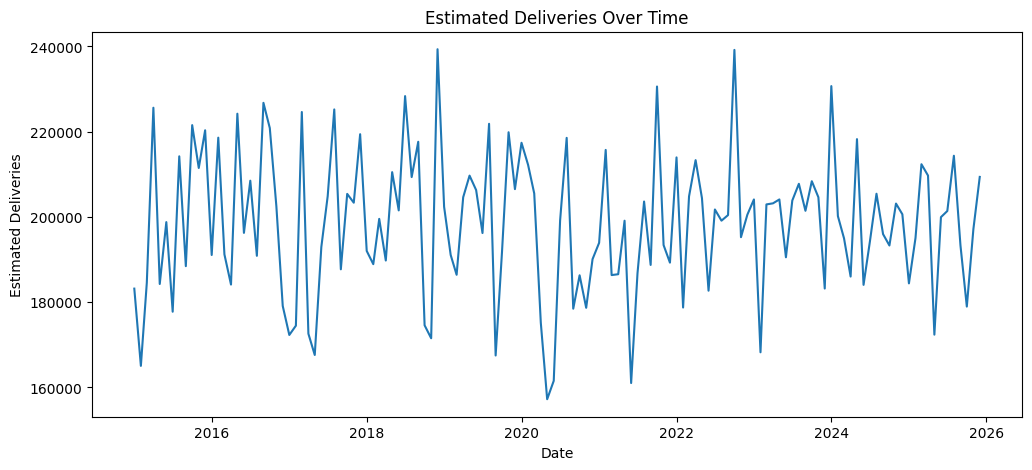

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(ts)
plt.title("Estimated Deliveries Over Time")
plt.xlabel("Date")
plt.ylabel("Estimated Deliveries")
plt.show()

In [42]:
train_size = int(len(ts) * 0.8)

train = ts[:train_size]
test = ts[train_size:]

installing the statsmodel using pip command for ARIMA import

In [47]:
pip install statsmodels

   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.5 MB ? eta -:--:--
   ------------ --------------------------- 2.9/9.5 MB 16.2 MB/s eta 0:00:01
   ------------------------------------ --- 8.7/9.5 MB 20.5 MB/s eta 0:00:01
   ---------------------------------------- 9.5/9.5 MB 19.0 MB/s  0:00:00

   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- -------


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [48]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(train, order=(5,1,0))
model_fit = model.fit()

print(model_fit.summary())
forecast = model_fit.forecast(steps=len(test))

mae = mean_absolute_error(test, forecast)
mse = mean_squared_error(test, forecast)
rmse = mse ** 0.5

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)

                                SARIMAX Results                                 
Dep. Variable:     Estimated_Deliveries   No. Observations:                  105
Model:                   ARIMA(5, 1, 0)   Log Likelihood               -1186.792
Date:                  Sun, 28 Jun 2026   AIC                           2385.585
Time:                          23:07:06   BIC                           2401.451
Sample:                      01-01-2015   HQIC                          2392.013
                           - 09-01-2023                                         
Covariance Type:                    opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4834      0.053     -9.161      0.000      -0.587      -0.380
ar.L2         -0.2716      0.057     -4.741      0.000      -0.384      -0.159
ar.L3         -0.1818      0.056    

C:\Users\MAYANK CHAUHAN\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\MAYANK CHAUHAN\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\MAYANK CHAUHAN\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


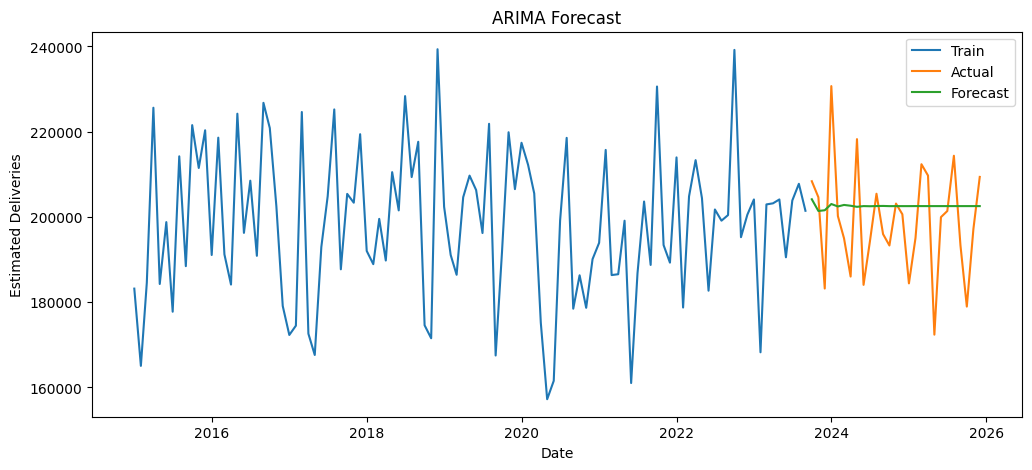

In [49]:
plt.figure(figsize=(12,5))

plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Actual")
plt.plot(test.index, forecast, label="Forecast")

plt.title("ARIMA Forecast")
plt.xlabel("Date")
plt.ylabel("Estimated Deliveries")
plt.legend()

plt.show()

Forecasting & Evaluation Table
We construct a forecast table comparing the Actual test data against predictions from both our XGBoost and Random Forest models for the first 20 records. We also calculate the absolute percentage error. Finally, a consolidated model comparison table summarizes MAE, RMSE, and R2, directly displaying which model performs best.

In [51]:
forecast_df = pd.DataFrame({
    'Actual': y_test.values[:20],
    'XGB_Predicted': xgb_pred[:20],
    'RF_Predicted': rf_pred[:20]
})

forecast_df['XGB_Error_%'] = np.abs((forecast_df['Actual'] - forecast_df['XGB_Predicted']) / forecast_df['Actual']) * 100
forecast_df['RF_Error_%'] = np.abs((forecast_df['Actual'] - forecast_df['RF_Predicted']) / forecast_df['Actual']) * 100
print("Forecast Table (First 20 Test Records):")
display(forecast_df.round(2))

comparison_data = {
    'Model': ['XGB', 'Random Forest'],
    'MAE': [mean_absolute_error(y_test, xgb_pred), mean_absolute_error(y_test, rf_pred)],
    'RMSE': [np.sqrt(mean_squared_error(y_test, xgb_pred)), np.sqrt(mean_squared_error(y_test, rf_pred))],
    'R²': [r2_score(y_test, xgb_pred), r2_score(y_test, rf_pred)]
}
comparison_df = pd.DataFrame(comparison_data)

print("\nModel Comparison Table:")
display(comparison_df.round(4))

Forecast Table (First 20 Test Records):


,Actual,XGB_Predicted,RF_Predicted,XGB_Error_%,RF_Error_%
0,6593,6689.169922,6803.18,1.46,3.19
1,14659,14334.870117,14176.95,2.21,3.29
2,6620,6823.770020,6962.48,3.08,5.17
3,9064,9028.440430,8834.06,0.39,2.54
4,13755,13332.290039,13277.64,3.07,3.47
5,6815,7236.319824,7161.29,6.18,5.08
6,16161,16496.050781,16582.28,2.07,2.61
7,10303,10324.040039,9906.24,0.20,3.85
8,11301,11339.830078,11187.25,0.34,1.01
9,11623,11146.900391,11042.72,4.10,4.99



Model Comparison Table:


,Model,MAE,RMSE,R²
0,XGB,221.6428,295.1294,0.9935
1,Random Forest,309.5306,387.3945,0.9888
